<a href="https://colab.research.google.com/github/HussamAlabrash/DSA210PROJECT/blob/main/DSA210.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Importing Libraries

In [25]:
!pip install pandas numpy matplotlib seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

## 2. Data Collection


In [26]:
from google.colab import files
uploaded = files.upload()

## 3. Loading the Data

In [27]:
econ = pd.read_csv("Middle_East_Economic_Data_1990_2024_with_Oil.csv")
conflict = pd.read_csv("MiddleEast_2015-2024_Nov01.csv")

## 4. Data Preparation

The conflict dataset is aggregated to create yearly country-level indicators such as total conflict events and fatalities.

In [28]:
conflict_agg = conflict.groupby(['country', 'year']).agg({
    'event_id_cnty': 'count',
    'fatalities': 'sum'
}).reset_index()

conflict_agg.rename(columns={
    'event_id_cnty': 'conflict_events'
}, inplace=True)

## 5. Filtering Data (2015–2024)

Only overlapping years between datasets are used.

In [29]:
econ_filtered = econ[(econ['Year'] >= 2015) & (econ['Year'] <= 2024)]

## 6. Merging Datasets

The datasets are merged using country and year.

In [30]:
# Make a safe copy to avoid pandas warning
econ_filtered = econ_filtered.copy()

# Clean country names to avoid mismatches
conflict_agg['country'] = conflict_agg['country'].str.strip().str.lower()
econ_filtered['Country'] = econ_filtered['Country'].str.strip().str.lower()

# Merge datasets
merged = econ_filtered.merge(
    conflict_agg,
    left_on=['Country', 'Year'],
    right_on=['country', 'year'],
    how='left'
)

# Fill missing conflict values
merged['conflict_events'] = merged['conflict_events'].fillna(0)
merged['fatalities'] = merged['fatalities'].fillna(0)

# Preview
merged.sample(10)

,Country,Country_Code,Year,Exports_pct_GDP,FDI_net_inflows_pct_GDP,GDP_current_USD,GDP_growth_annual_pct,GDP_per_capita_current_USD,Imports_pct_GDP,Inflation_consumer_prices_annual_pct,Life_expectancy_years,Unemployment_total_pct,Brent_Oil_Price_USD_per_barrel,country,year,conflict_events,fatalities
89,oman,OMN,2024,66.072566,11.635118,1.071372e+11,1.631632,20285.227290,48.780105,0.593589,NaN,3.203,85.0,oman,2024.0,4.0,9.0
103,saudi arabia,SAU,2018,35.520983,1.369457,8.865648e+11,3.226951,29360.065897,23.581927,2.465943,78.750,6.029,55.0,saudi arabia,2018.0,862.0,1514.0
19,egypt,EGY,2024,16.376242,11.971935,3.890599e+11,2.399169,3338.473714,23.224510,28.270590,NaN,6.817,85.0,NaN,NaN,0.0,0.0
12,egypt,EGY,2017,15.014087,2.983016,2.483628e+11,4.181221,2395.103333,27.818048,29.506608,70.709,11.767,60.0,NaN,NaN,0.0,0.0
32,iraq,IRQ,2017,33.916063,-2.687994,1.872177e+11,-1.819750,4759.284644,25.864849,0.184059,69.788,13.020,60.0,iraq,2017.0,5287.0,31956.0
84,oman,OMN,2019,49.492903,2.269089,8.806086e+10,-1.128638,19180.186415,36.985298,0.490815,79.946,2.045,50.0,oman,2019.0,4.0,0.0
76,lebanon,LBN,2021,26.025628,2.592901,2.313194e+10,-7.001239,4045.373911,52.802993,154.756096,73.650,12.715,70.0,lebanon,2021.0,3211.0,74.0
18,egypt,EGY,2023,19.106091,2.485464,3.959261e+11,3.760281,3456.789685,21.344309,33.884776,71.633,6.753,80.0,NaN,NaN,0.0,0.0
20,iran,IRN,2015,18.720835,0.500988,4.091917e+11,-1.424885,4952.733555,20.701754,12.484682,75.907,11.166,70.0,NaN,NaN,0.0,0.0
10,egypt,EGY,2015,13.183845,2.102581,3.293666e+11,4.372019,3306.981594,21.662097,10.370490,70.135,13.052,70.0,NaN,NaN,0.0,0.0


### Conflict Events vs GDP Growth

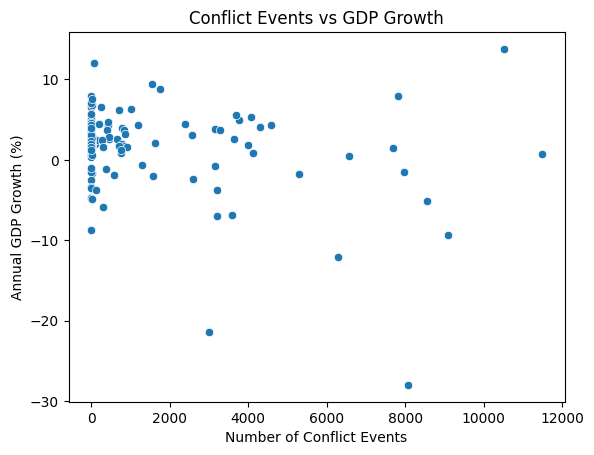

In [31]:
plt.figure()

sns.scatterplot(data=merged, x='conflict_events', y='GDP_growth_annual_pct')

plt.title("Conflict Events vs GDP Growth")
plt.xlabel("Number of Conflict Events")
plt.ylabel("Annual GDP Growth (%)")

plt.show()

This scatter plot illustrates the relationship between the number of conflict events and GDP growth across Middle Eastern countries. The points appear widely dispersed, indicating that the relationship is not very strong. However, there is a slight downward trend suggesting that higher levels of conflict may be associated with lower GDP growth. Additionally, observations with very high conflict events tend to correspond with more negative or volatile GDP growth values, highlighting the potential economic instability caused by conflict.

### Fatalities vs Inflation

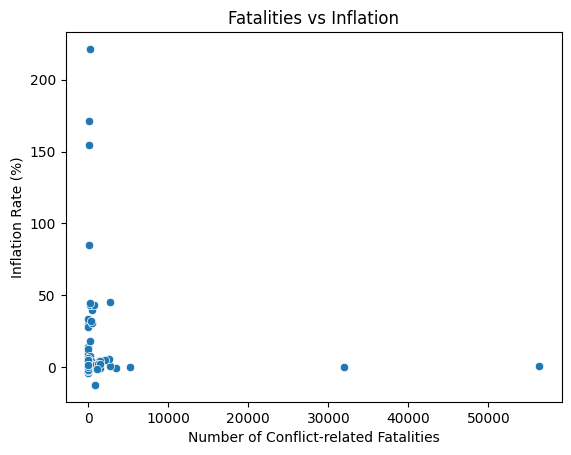

In [32]:
plt.figure()

sns.scatterplot(
    data=merged,
    x='fatalities',
    y='Inflation_consumer_prices_annual_pct'
)

plt.title("Fatalities vs Inflation")
plt.xlabel("Number of Conflict-related Fatalities")
plt.ylabel("Inflation Rate (%)")

plt.show()

This plot examines the relationship between conflict-related fatalities and inflation rates. The data points are scattered without a clear upward or downward trend, suggesting that there is no strong relationship between fatalities and inflation. This indicates that while conflict may influence economic conditions, its direct impact on inflation is not clearly observable in this dataset.

### Oil Price vs GDP Growth

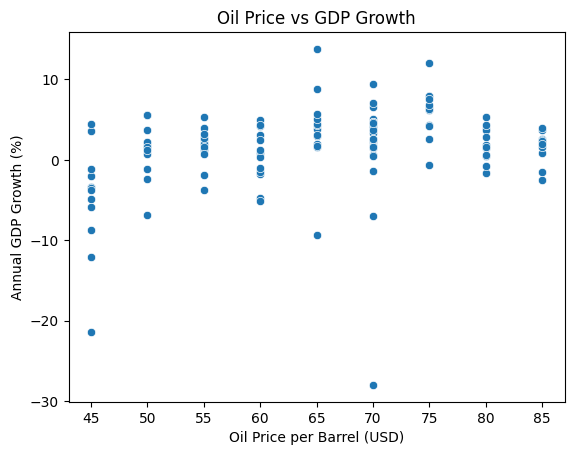

In [33]:
plt.figure()

sns.scatterplot(
    data=merged,
    x='Brent_Oil_Price_USD_per_barrel',
    y='GDP_growth_annual_pct'
)

plt.title("Oil Price vs GDP Growth")
plt.xlabel("Oil Price per Barrel (USD)")
plt.ylabel("Annual GDP Growth (%)")

plt.show()

This scatter plot shows the relationship between oil prices and GDP growth. A slight positive trend can be observed, indicating that higher oil prices are generally associated with higher GDP growth. This is expected for oil-dependent economies, where increases in oil prices contribute positively to national income and economic performance.

### Conflict Events Over Time

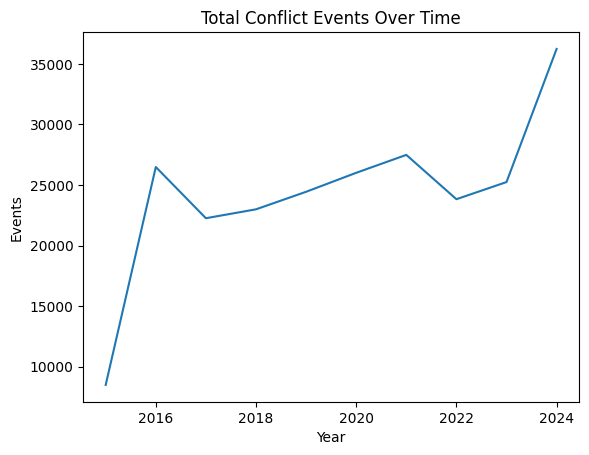

In [34]:
conflict_trend = merged.groupby('Year')['conflict_events'].sum()

plt.figure()
conflict_trend.plot()
plt.title("Total Conflict Events Over Time")
plt.xlabel("Year")
plt.ylabel("Events")
plt.show()

This scatter plot shows the relationship between oil prices and GDP growth. A slight positive trend can be observed, indicating that higher oil prices are generally associated with higher GDP growth. This is expected for oil-dependent economies, where increases in oil prices contribute positively to national income and economic performance.

### Hypothesis 1
H₀: Conflict has no effect on GDP growth  
H₁: Conflict negatively affects GDP growth

In [35]:
df = merged[['conflict_events', 'GDP_growth_annual_pct']].dropna()

corr, p_value = pearsonr(df['conflict_events'], df['GDP_growth_annual_pct'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.24399904799421807
P-value: 0.006534432771616528


The correlation between conflict events and GDP growth is negative (-0.244), indicating that higher levels of conflict are associated with lower GDP growth. The p-value (0.0065) is less than 0.05, which means the result is statistically significant. Therefore, we reject the null hypothesis and conclude that conflict has a negative effect on GDP growth.

### Hypothesis 2
H₀: Fatalities does not affect inflation  
H₁: Fatalities increases inflation

In [36]:
df = merged[['fatalities', 'Inflation_consumer_prices_annual_pct']].dropna()

corr, p_value = pearsonr(df['fatalities'], df['Inflation_consumer_prices_annual_pct'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.04134737561611397
P-value: 0.6538726422751064


The correlation between fatalities and inflation is very weak (-0.041), suggesting almost no relationship between the two variables. The p-value (0.6539) is greater than 0.05, indicating that the result is not statistically significant. Therefore, we fail to reject the null hypothesis and conclude that there is no significant relationship between conflict and inflation.

### Hypothesis 3
H₀: Conflict has no effect on FDI  
H₁: Conflict reduces FDI

In [37]:
df = merged[['conflict_events', 'FDI_net_inflows_pct_GDP']].dropna()

corr, p_value = pearsonr(df['conflict_events'], df['FDI_net_inflows_pct_GDP'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.38378482552189574
P-value: 1.1763359195311098e-05


The correlation between conflict events and FDI is negative (-0.384), indicating that higher conflict levels are associated with lower foreign direct investment. The p-value (1.18e-05) is much smaller than 0.05, showing strong statistical significance. Therefore, we reject the null hypothesis and conclude that conflict reduces FDI inflows.

### Hypothesis 4
H₀: Oil price has no effect on GDP  
H₁: Oil price affects GDP

In [38]:
df = merged[['Brent_Oil_Price_USD_per_barrel', 'GDP_growth_annual_pct']].dropna()

corr, p_value = pearsonr(df['Brent_Oil_Price_USD_per_barrel'], df['GDP_growth_annual_pct'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.29928216968072113
P-value: 0.0007717590245511473


The correlation between oil prices and GDP growth is positive (0.299), suggesting that higher oil prices are associated with higher GDP growth. The p-value (0.00077) is less than 0.05, indicating statistical significance. Therefore, we reject the null hypothesis and conclude that oil prices have a significant effect on GDP growth.

## Conclusion

The analysis shows that conflict intensity is negatively associated with GDP growth and negatively associated with FDI inflows. However, no statistically significant relationship was found between conflict and inflation. Oil prices also play a significant role in economic performance, especially in oil-dependent countries. These findings suggest that both political instability and global oil markets are important factors influencing economic outcomes in the Middle East.

##Machine Learning

In this section, supervised machine learning models are applied to predict annual GDP growth using economic indicators, oil prices, and conflict-related variables. Since GDP growth is a numerical variable, this is a regression problem.

The models used are Baseline Mean Model, Linear Regression, kNN Regression, Decision Tree Regression, and Random Forest Regression. These models are suitable because the course covered supervised learning, regression, kNN, decision trees, model evaluation, and ensemble learning.

In [39]:
# Import ML Libraries

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd

The target variable is annual GDP growth. The input features include economic variables, oil price, conflict events, fatalities, and year. Rows with missing target values are removed because the model cannot learn without the true GDP growth value. Missing feature values are handled using median imputation.

In [40]:
# Prepare ML Dataset
# Select features and target variable for machine learning
ml_columns = [
    'Exports_pct_GDP',
    'FDI_net_inflows_pct_GDP',
    'GDP_per_capita_current_USD',
    'Imports_pct_GDP',
    'Inflation_consumer_prices_annual_pct',
    'Life_expectancy_years',
    'Unemployment_total_pct',
    'Brent_Oil_Price_USD_per_barrel',
    'conflict_events',
    'fatalities',
    'Year',
    'GDP_growth_annual_pct'
]

ml_data = merged[ml_columns].copy()

# Drop rows where the target variable is missing
ml_data = ml_data.dropna(subset=['GDP_growth_annual_pct'])

# Sort by year because the data has a time component
ml_data = ml_data.sort_values(by='Year')

# Define features and target
X = ml_data.drop(columns=['GDP_growth_annual_pct'])
y = ml_data['GDP_growth_annual_pct']

print("ML dataset shape:", ml_data.shape)
print("Features used:")
print(X.columns.tolist())

ML dataset shape: (123, 12)
Features used:
['Exports_pct_GDP', 'FDI_net_inflows_pct_GDP', 'GDP_per_capita_current_USD', 'Imports_pct_GDP', 'Inflation_consumer_prices_annual_pct', 'Life_expectancy_years', 'Unemployment_total_pct', 'Brent_Oil_Price_USD_per_barrel', 'conflict_events', 'fatalities', 'Year']


A chronological train-test split is used. Older years are used for training, while later years are used for testing. This avoids using future information to predict the past and is more suitable for data with a time component.

In [41]:
# Train/Test Split
# Chronological split
train_data = ml_data[ml_data['Year'] <= 2021]
test_data = ml_data[ml_data['Year'] > 2021]

X_train = train_data.drop(columns=['GDP_growth_annual_pct'])
y_train = train_data['GDP_growth_annual_pct']

X_test = test_data.drop(columns=['GDP_growth_annual_pct'])
y_test = test_data['GDP_growth_annual_pct']

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (88, 11)
Testing set size: (35, 11)


Several machine learning models are applied. A baseline mean model is included as a simple comparison point. Linear Regression is used as a simple regression model. kNN Regression predicts by averaging nearby observations. Decision Tree Regression learns rule-based splits, while Random Forest Regression combines many decision trees to improve prediction performance.

In [42]:
# Define Models

# Baseline model
baseline_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DummyRegressor(strategy="mean"))
])

# Models that need scaling
linear_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

knn_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor())
])

# Tree-based models
decision_tree_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeRegressor(random_state=42))
])

random_forest_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=42))
])

models = {
    "Baseline Mean Model": baseline_model,
    "Linear Regression": linear_model,
    "kNN Regression": knn_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

Hyperparameter tuning is applied to kNN Regression, Decision Tree, and Random Forest. This is done because these models have settings that control model complexity, such as the number of neighbors in kNN, the maximum depth of a tree, and the number of trees in a Random Forest. The best hyperparameters are selected using cross-validation on the training data only.

In [43]:
# Hyperparameter Tuning

# Time-series cross-validation for tuning
tscv = TimeSeriesSplit(n_splits=3)

# Hyperparameter grids
param_grids = {
    "kNN Regression": {
        "model__n_neighbors": [3, 5, 7, 9]
    },

    "Decision Tree": {
        "model__max_depth": [2, 3, 4, 5, None],
        "model__min_samples_split": [2, 5, 10]
    },

    "Random Forest": {
        "model__n_estimators": [50, 100, 200],
        "model__max_depth": [3, 5, 7, None],
        "model__max_features": ["sqrt", None]
    }
}

tuned_models = {}

for name, model in models.items():

    if name in param_grids:
        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grids[name],
            scoring="neg_root_mean_squared_error",
            cv=tscv
        )

        grid.fit(X_train, y_train)
        tuned_models[name] = grid.best_estimator_

        print(name)
        print("Best parameters:", grid.best_params_)
        print("Best CV RMSE:", -grid.best_score_)
        print()

    else:
        model.fit(X_train, y_train)
        tuned_models[name] = model

kNN Regression
Best parameters: {'model__n_neighbors': 5}
Best CV RMSE: 4.70303960620127

Decision Tree
Best parameters: {'model__max_depth': 2, 'model__min_samples_split': 2}
Best CV RMSE: 6.684005759863566

Random Forest
Best parameters: {'model__max_depth': 3, 'model__max_features': 'sqrt', 'model__n_estimators': 200}
Best CV RMSE: 5.2018979861873005



Hyperparameter tuning was applied to kNN Regression, Decision Tree, and Random Forest. For kNN Regression, the best number of neighbors was 5. For the Decision Tree, the best parameters were max_depth = 2 and min_samples_split = 2. For Random Forest, the best parameters were max_depth = 3, max_features = sqrt, and n_estimators = 200. These results show that simpler tree models were preferred, which may indicate that the dataset is small and complex models may overfit the training data.

The models are evaluated using MAE, RMSE, and R² score. MAE and RMSE measure prediction error, so lower values indicate better performance. R² measures how much variation in GDP growth is explained by the model, so higher values are better. The baseline mean model is used to check whether the ML models perform better than a simple average prediction.

In [44]:
# Evaluate Models

results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results).sort_values(by="RMSE")
results_df

,Model,MAE,RMSE,R2 Score
3,Decision Tree,2.434519,3.205940,-0.066320
4,Random Forest,2.627541,3.442525,-0.229508
2,kNN Regression,3.023400,3.616166,-0.356668
0,Baseline Mean Model,3.073210,3.914248,-0.589548
1,Linear Regression,5.348286,6.436683,-3.298344


The best model is selected based on the lowest RMSE value. RMSE is useful because it penalizes larger prediction errors more strongly. The table below compares actual GDP growth values with the predicted values from the best-performing model.

In [45]:
# Best Model Predictions

# Select the best model based on lowest RMSE
best_model_name = results_df.iloc[0]["Model"]
best_model = tuned_models[best_model_name]

best_predictions = best_model.predict(X_test)

prediction_comparison = pd.DataFrame({
    "Actual GDP Growth": y_test.values,
    "Predicted GDP Growth": best_predictions
})

print("Best model:", best_model_name)
prediction_comparison.head(10)

Best model: Decision Tree


,Actual GDP Growth,Predicted GDP Growth
0,6.587846,2.437139
1,6.180161,2.437139
2,7.514484,2.437139
3,4.184970,2.437139
4,7.959048,2.437139
5,4.352811,2.437139
6,2.647435,2.437139
7,6.263263,2.437139
8,12.000587,2.437139
9,-0.621679,2.437139


The model comparison shows that the Decision Tree model performed best among the tested models, with the lowest RMSE value of 3.2059 and the lowest MAE value of 2.4345. Random Forest and kNN Regression also performed better than the baseline mean model based on RMSE. Linear Regression performed the worst, suggesting that the relationship between the selected economic and conflict-related variables and GDP growth is not well captured by a simple linear model.

Although the Decision Tree had the best performance, its R² score is negative. This means that the model has limited explanatory power on the test set. Therefore, while the Decision Tree produced the lowest prediction error among the tested models, the overall predictive performance remains weak. This may be due to the small dataset size, economic volatility, missing values, and the complexity of predicting GDP growth using only these variables.

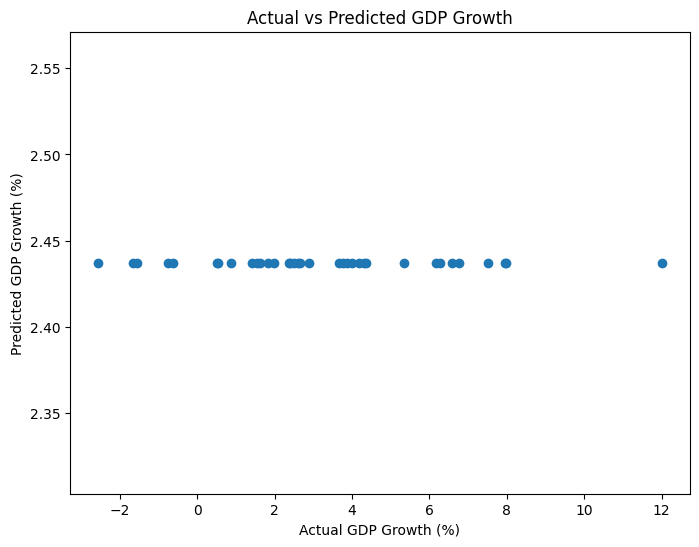

In [46]:
# Actual vs Predicted Plot

plt.figure(figsize=(8, 6))

plt.scatter(
    prediction_comparison["Actual GDP Growth"],
    prediction_comparison["Predicted GDP Growth"]
)

plt.title("Actual vs Predicted GDP Growth")
plt.xlabel("Actual GDP Growth (%)")
plt.ylabel("Predicted GDP Growth (%)")

plt.show()

This plot compares the actual GDP growth values with the predicted GDP growth values from the best-performing model. If the model predicts well, the points should generally follow a diagonal pattern where predicted values are close to actual values. Points far from this pattern indicate larger prediction errors.

The actual vs predicted plot shows that the best model, the Decision Tree, predicts nearly the same GDP growth value for many test observations. This indicates that the model is making conservative predictions rather than capturing the full variation in GDP growth. The plot confirms that the model has limited predictive power, especially for very high or very low GDP growth values. This is consistent with the negative R² score observed in the evaluation table.

Random Forest feature importance is used to interpret which variables contributed most to predicting GDP growth. Higher importance values mean that the model relied more heavily on that feature.

In [47]:
# Random Forest Feature Importance

# Fit tuned Random Forest model
rf_pipeline = tuned_models["Random Forest"]
rf_pipeline.fit(X_train, y_train)

# Extract Random Forest model from pipeline
rf_model = rf_pipeline.named_steps["model"]

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
4,Inflation_consumer_prices_annual_pct,0.156858
7,Brent_Oil_Price_USD_per_barrel,0.143946
5,Life_expectancy_years,0.113754
0,Exports_pct_GDP,0.105290
8,conflict_events,0.103007
2,GDP_per_capita_current_USD,0.073772
6,Unemployment_total_pct,0.072471
1,FDI_net_inflows_pct_GDP,0.064329
3,Imports_pct_GDP,0.063929
9,fatalities,0.063257


The Random Forest feature importance results show that inflation, oil price, life expectancy, exports, and conflict events were the most important variables for predicting GDP growth. Inflation had the highest importance score, followed by Brent oil price and life expectancy. Conflict events also had a relatively high importance score, suggesting that conflict intensity contributes to GDP growth prediction in the model. Fatalities had lower importance compared to conflict events, which may indicate that the number of conflict events is more informative than the number of deaths for this prediction task.

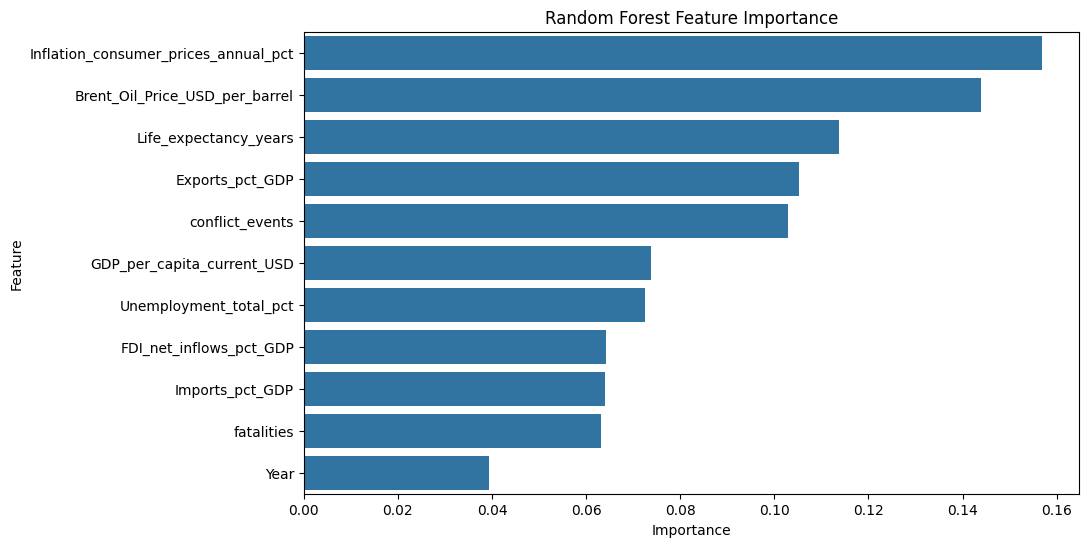

In [48]:
# Feature Importance Plot

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

Overall, the machine learning results show that GDP growth is difficult to predict accurately using the available economic, oil price, and conflict-related variables. Among the tested models, the Decision Tree performed best based on RMSE and MAE, but its negative R² score shows that the model still has weak explanatory power. Random Forest feature importance suggests that inflation, oil price, life expectancy, exports, and conflict events were the most influential predictors. These findings suggest that both macroeconomic factors and conflict-related variables are relevant, but the dataset may be too small and volatile for highly accurate GDP growth prediction.

In conclusion, this machine learning section applies supervised regression models to predict annual GDP growth. Multiple models were compared, including a baseline model, Linear Regression, kNN Regression, Decision Tree Regression, and Random Forest Regression. Hyperparameter tuning was applied to the models where tuning was most relevant. The final model comparison is based on MAE, RMSE, and R² score, while Random Forest feature importance is used to interpret which variables were most influential in predicting GDP growth.